In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression,ElasticNet,HuberRegressor,RANSACRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [128]:
from config import CONFIG
df=pd.read_excel(r'C:\Users\aarsh\OneDrive\Desktop\MStats_project\Mathematical_Stats_project\data\raw\day.xlsx')
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01 00:00:00,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,2018-02-01 00:00:00,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,2018-03-01 00:00:00,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,2018-04-01 00:00:00,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,2018-05-01 00:00:00,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


In [127]:
output_cols=['casual', 'registered', 'cnt']
input_cols=[x for x in df.columns if x not in output_cols]
desc=df.describe()

In [110]:
X=df[input_cols]
y=df[output_cols[0]]

In [111]:
# Dropping instant and dteday as these are redundant
X.drop(columns=['instant','dteday'],inplace=True)

C:\Users\aarsh\AppData\Local\Temp\ipykernel_20656\407472407.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(columns=['instant','dteday'],inplace=True)


<Axes: >

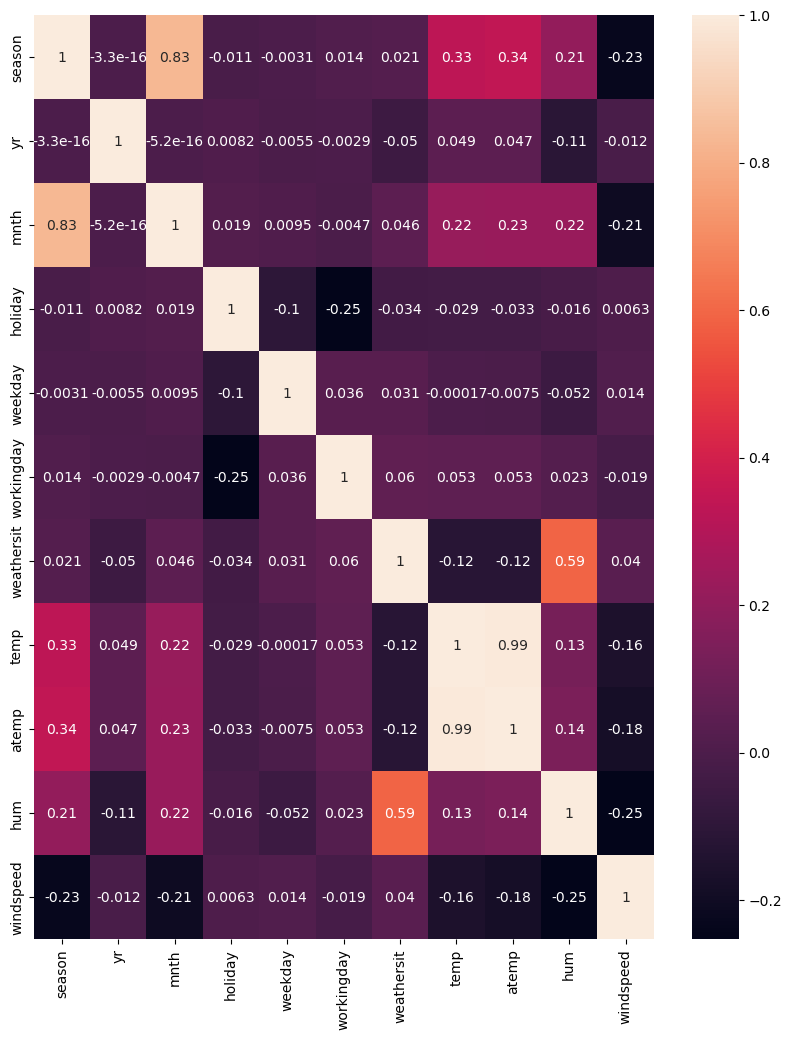

In [112]:
plt.figure(figsize=(10,12))
sns.heatmap(X.corr(),annot=True)

In [113]:
# atemp is highly correlated with temp and practically doesn't provide any new information. So, dropping it as it could make the hat matrix unstable/ singular
X.drop(columns=['atemp'],inplace=True)

C:\Users\aarsh\AppData\Local\Temp\ipykernel_20656\3153772349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(columns=['atemp'],inplace=True)


In [114]:
# Dataframe containing columnwise number of unique values and data type
desc=pd.DataFrame({'dtypes':X.dtypes,'unique':X.nunique()})

In [115]:
num_cols=desc[desc.unique>13].index
cat_cols=desc[desc.unique<13].index

In [116]:
ohe=OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')
X_trans=ohe.fit_transform(X[cat_cols])
X_cat=pd.DataFrame(X_trans,columns=ohe.get_feature_names_out(cat_cols))
X=pd.concat([X[num_cols],X_cat],axis=1)
train_idx=int(0.7*len(y))

                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     75.77
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          1.20e-187
Time:                        16:52:10   Log-Likelihood:                -5305.3
No. Observations:                 730   AIC:                         1.067e+04
Df Residuals:                     702   BIC:                         1.080e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          716.8795    108.156      6.628   

Text(0, 0.5, 'Residuals')

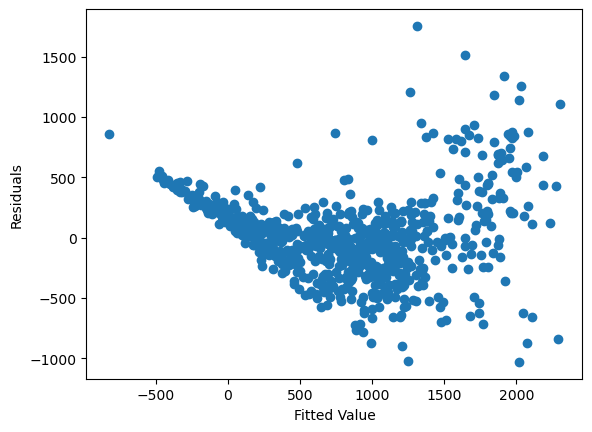

In [130]:
sc=StandardScaler()
lr=LinearRegression()
X_train,X_test=X.iloc[:train_idx,:],X.iloc[train_idx:,:]
y_train,y_test=y[:train_idx],y[train_idx:]
sc.fit_transform(X)
sc.transform(X)
model=sm.OLS(y,sm.add_constant(X)).fit()
print(model.summary())
y_pred=model.predict(sm.add_constant(X))
plt.scatter(y_pred,model.resid)
plt.xlabel('Fitted Value')
plt.ylabel('Residuals')

In [118]:
y_pred=model.predict(sm.add_constant(X))
# pd.to_pickle(plt.scatter(y_pred,model.resid),'Residual_plot_poly.pkl')
r2_score(y,y_pred)

0.7445100177616156

      feature         coef   p_value
const   const -1516.341108  0.003800
x1         x1    23.851484  0.494037
x2         x2    28.422175  0.024017
x3         x3    73.159922  0.001498
x4         x4   154.702790  0.366209
...       ...          ...       ...
x430     x430    98.896510  0.234992
x431     x431   187.069470  0.965863
x432     x432  -136.247063  0.353683
x433     x433     0.000000       NaN
x434     x434    -4.287090  0.999654

[435 rows x 3 columns]


Text(0, 0.5, 'Residuals')

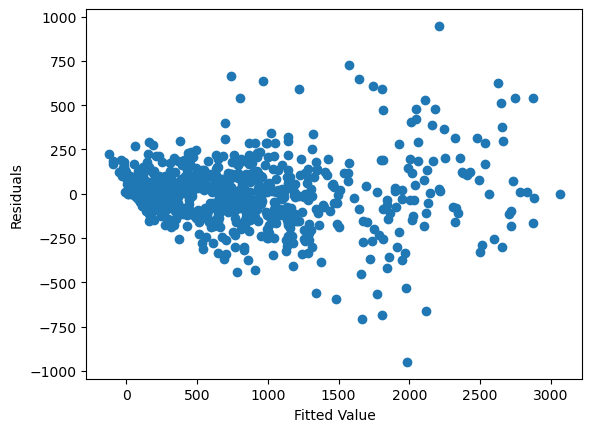

In [131]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

X_poly_const = sm.add_constant(X_poly)

model_poly = sm.OLS(y, X_poly_const).fit()

y_pred_poly = model_poly.predict(X_poly_const)
import pandas as pd

results_df_poly = pd.DataFrame({
    "feature": model_poly.model.exog_names,
    "coef": model_poly.params,
    "p_value": model_poly.pvalues
})

print(results_df_poly)
plt.scatter(y_pred_poly,model_poly.resid)
plt.xlabel('Fitted Value')
plt.ylabel('Residuals')

(array([  1.,   0.,   0.,   3.,   1.,   3.,   4.,   8.,  21.,  33.,  73.,
        124., 197., 110.,  76.,  33.,  19.,   6.,   4.,   5.,   5.,   2.,
          1.,   0.,   1.]),
 array([-949.53234956, -873.64949754, -797.76664552, -721.88379351,
        -646.00094149, -570.11808947, -494.23523746, -418.35238544,
        -342.46953342, -266.5866814 , -190.70382939, -114.82097737,
         -38.93812535,   36.94472666,  112.82757868,  188.7104307 ,
         264.59328272,  340.47613473,  416.35898675,  492.24183877,
         568.12469078,  644.0075428 ,  719.89039482,  795.77324684,
         871.65609885,  947.53895087]),
 <BarContainer object of 25 artists>)

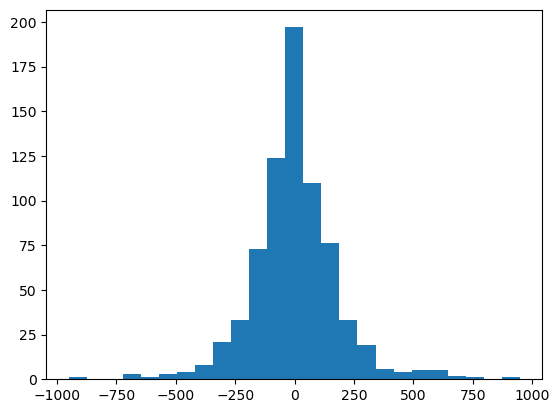

In [120]:
plt.hist(model_poly.resid,bins=25)

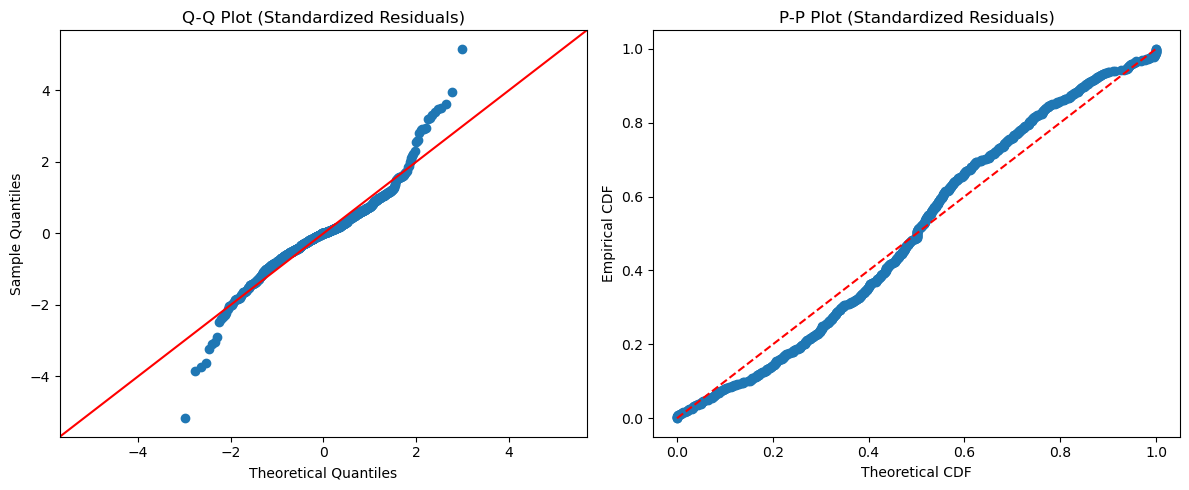

In [121]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

fig, ax = plt.subplots(1, 2, figsize=(12,5))

residuals = model_poly.resid

# 🔥 FIX 1: standardize residuals (CRITICAL)
residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)

# Q-Q Plot
sm.qqplot(residuals_std, line='45', ax=ax[0])
ax[0].set_title("Q-Q Plot (Standardized Residuals)")

# 🔥 FIX 2: use standardized residuals for consistency
sorted_res = np.sort(residuals_std)

# 🔥 FIX 3: better ECDF (starts at 0, ends at 1 properly)
ecdf = np.linspace(0, 1, len(sorted_res))

# 🔥 FIX 4: theoretical CDF should be standard normal now
theoretical_cdf = stats.norm.cdf(sorted_res)

# P-P Plot
ax[1].scatter(theoretical_cdf, ecdf)
ax[1].plot([0,1], [0,1], 'r--')
ax[1].set_title("P-P Plot (Standardized Residuals)")
ax[1].set_xlabel("Theoretical CDF")
ax[1].set_ylabel("Empirical CDF")

plt.tight_layout()
plt.show()

In [122]:
y_log = np.log1p(y)

model_log = sm.OLS(y_log, X_poly_const).fit()
y_pred = np.expm1(model_log.predict(X_poly_const))
print(model_poly.rsquared_adj,model.rsquared_adj,model_log.rsquared_adj)


0.8886419280604598 0.7346834799832163 0.9228766159517727


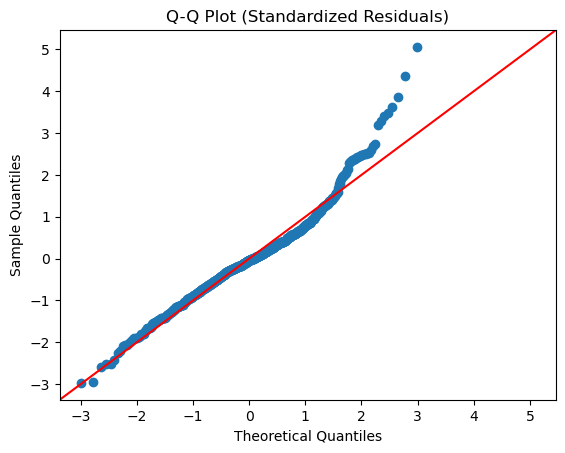

In [123]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Residuals from your model
residuals = model.resid

# Standardize (important for proper comparison)
residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)

# Q-Q Plot
sm.qqplot(residuals_std, line='45')
plt.title("Q-Q Plot (Standardized Residuals)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

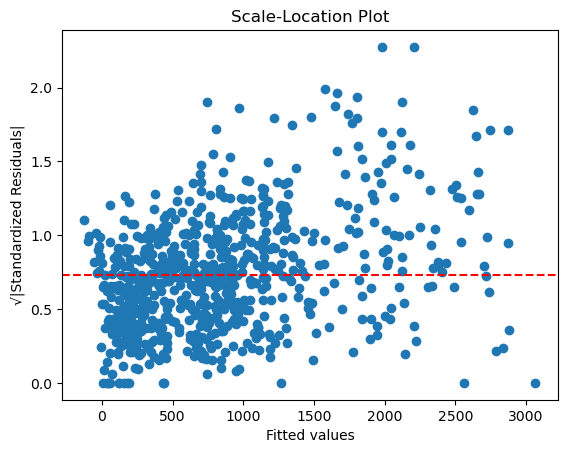

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# residuals
residuals = model_poly.resid

# standardized residuals
res_std = (residuals - np.mean(residuals)) / np.std(residuals)

# fitted values
fitted = model_poly.fittedvalues

# scale-location values
scale_loc = np.sqrt(np.abs(res_std))

plt.scatter(fitted, scale_loc)
plt.axhline(np.mean(scale_loc), color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("√|Standardized Residuals|")
plt.title("Scale-Location Plot")
plt.show()

In [125]:
from scipy.stats import jarque_bera

jb_stat, p_value = jarque_bera(residuals)
print(p_value)

3.766160510836653e-99


In [126]:
import numpy as np
from scipy.stats import skew, kurtosis

residuals = model_poly.resid

# Skewness
sk = skew(residuals)

# Kurtosis (excess kurtosis by default)
kt = kurtosis(residuals)  # excess (normal = 0)

print("Skewness:", sk)
print("Excess Kurtosis:", kt)
print("Kurtosis (raw):", kt + 3)  # normal = 3

Skewness: 0.19240056292528354
Excess Kurtosis: 3.8410438756267133
Kurtosis (raw): 6.841043875626713


In [132]:
from statsmodels.stats.diagnostic import linear_reset

reset = linear_reset(model_poly, power=2, use_f=True)
print(reset)

<F test: F=80.78509300210533, p=6.2733325062533165e-18, df_denom=467, df_num=1>


In [ ]:
from statsmodels.stats.diagnostic import het_white

white = het_white(model_poly.resid, model_poly.model.exog)

print("p-value:", white[1])